In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import math
import re

In [2]:
# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)
import plotting
import utils

In [3]:
ROOT_FOLDER = os.path.dirname(os.getcwd())
RUNS_FOLDER = os.path.join(ROOT_FOLDER, "runs")
SINGLE_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "single_runs")
BATCH_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "batch_runs")
TEST_BATCH_RUNS_FOLDER = os.path.join(BATCH_RUNS_FOLDER, "test")

In [4]:
batch_name = "37-v0-v1-v2-v3"
batch_folder = os.path.join(BATCH_RUNS_FOLDER, batch_name)

In [5]:
test_folders = [
    os.path.join(TEST_BATCH_RUNS_FOLDER, f) for f in os.listdir(TEST_BATCH_RUNS_FOLDER)
]
batch_folder_names = [
    "Apr02_Wed_h11-GTSEP_v1a_multi-37_ES_PT",
    "Apr08_Tue_h10-GTSEP_v1a_multi-37_ES_PT",
]

folders_to_explore = [os.path.join(SINGLE_RUNS_FOLDER, f) for f in batch_folder_names]
folders_to_explore

['c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr02_Wed_h11-GTSEP_v1a_multi-37_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr08_Tue_h10-GTSEP_v1a_multi-37_ES_PT']

In [6]:
# Setup the folders to explore and their display name
folder1 = os.path.join(BATCH_RUNS_FOLDER, "1_GTSEP_v0-No name-Feb18_Tue_h08")
folder2 = os.path.join(BATCH_RUNS_FOLDER, "2_GTSEP_v1-No name-Feb18_Tue_h08")
folder3 = os.path.join(SINGLE_RUNS_FOLDER, "GTSEP_v2-No name-Feb19_Wed_h09")
# results_folders_to_explore = [folder1, folder2,folder3]
results_folders_to_explore = folders_to_explore
display_names = ["Old", "New"]
MAX_COLUMNS = 2

# Alternatively explore all folders in a batch directory

## Figures

In [7]:
def categorize_png_files(folder):
    figures_path = os.path.join(folder, "results", "figures")
    categorized_files = {
        "grid": [],
        "bar": [],
        "battery_general": [],
        "battery_hourly_soc": [],
        "battery_city_soc": [],
        "remaining": [],
    }

    for root, _, files in os.walk(figures_path):
        for file in files:
            if file.endswith(".png"):
                relative_path = os.path.relpath(os.path.join(root, file), figures_path)

                # Normalize to use forward slashes for regex compatibility
                relative_path = relative_path.replace("\\", "/")

                # Grid figures
                if relative_path.startswith("grid"):
                    categorized_files["grid"].append(relative_path)

                # Bar figures
                elif relative_path.startswith("bar"):
                    categorized_files["bar"].append(relative_path)

                # Battery subfolder
                elif "batteries" in relative_path:
                    if re.match(
                        r"batteries/\d+_plot_battery_average_hourly_soc_month_",
                        relative_path,
                    ):
                        categorized_files["battery_hourly_soc"].append(relative_path)
                    elif re.match(
                        r"batteries/[A-Za-z]+_plot_battery_average_hourly_soc_by_month_",
                        relative_path,
                    ):
                        categorized_files["battery_city_soc"].append(relative_path)
                    else:
                        categorized_files["battery_general"].append(relative_path)

                # Remaining figures
                else:
                    categorized_files["remaining"].append(relative_path)

    return categorized_files


# Get categorized PNG files from the first folder
reference_folder = results_folders_to_explore[0]
png_categories = categorize_png_files(reference_folder)


# Function to display grouped images
def display_images(image_group, title):
    print("=" * 80)
    print(f"Showing: {title}")
    print("=" * 80)

    if not image_group:
        print(f"No images found for {title}.")
        return

    num_folders = len(results_folders_to_explore)
    num_rows = math.ceil(
        num_folders / MAX_COLUMNS
    )  # Dynamically calculate number of rows

    for png_file in image_group:
        fig, axes = plt.subplots(
            num_rows, MAX_COLUMNS, figsize=(8 * MAX_COLUMNS, 5 * num_rows)
        )

        # Ensure axes is always a 2D list for easy indexing
        if num_rows == 1:
            axes = [axes]  # Convert to list of lists for consistency
        if MAX_COLUMNS == 1:
            axes = [
                [ax] for ax in axes
            ]  # Ensure row-based structure if only one column

        # Flatten for easier iteration
        axes = [ax for row in axes for ax in row]

        for idx, (folder, name) in enumerate(
            zip(results_folders_to_explore, display_names)
        ):
            img_path = os.path.join(folder, "results", "figures", png_file)

            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
                axes[idx].imshow(img)
                axes[idx].axis("off")
                axes[idx].set_title(name, fontsize=10)
            else:
                axes[idx].set_visible(False)

        # Hide unused subplots
        for ax in axes[num_folders:]:
            ax.set_visible(False)

        plt.suptitle(png_file, fontsize=12)
        plt.tight_layout()
        plt.show()


# Display images in the correct order
display_images(png_categories["grid"], "Grid-Related Figures")
display_images(png_categories["bar"], "Bar Figures")
display_images(png_categories["battery_general"], "Battery - General Figures")
# display_images(png_categories["battery_hourly_soc"], "Battery - Hourly SOC Figures")
# display_images(png_categories["battery_city_soc"], "Battery - City SOC Figures")
display_images(png_categories["remaining"], "Remaining Figures")

Showing: Grid-Related Figures
No images found for Grid-Related Figures.
Showing: Bar Figures
No images found for Bar Figures.
Showing: Battery - General Figures
No images found for Battery - General Figures.
Showing: Remaining Figures
No images found for Remaining Figures.


## Tables

In [8]:
# Dictionary to store lists of dataframes for each detected table
merged_tables = {}

# Loop over each experiment folder
for folder, name in zip(results_folders_to_explore, display_names):
    tables_path = os.path.join(folder, "results", "tables")

    if os.path.exists(tables_path):
        # Get all CSV filenames in the tables folder
        table_files = [f for f in os.listdir(tables_path) if f.endswith(".csv")]

        for table_file in table_files:
            table_path = os.path.join(tables_path, table_file)
            table_key = table_file.replace(".csv", "")  # key without extension

            # First, read the CSV without specifying an index to count rows
            temp_df = pd.read_csv(table_path)

            if len(temp_df) > 1:
                # For tables with more than one row, we assume the CSV was saved with an index.
                # Read the CSV using the first column as the index.
                df = pd.read_csv(table_path, index_col=0)

                # Preserve the existing index name (if it’s None, set a default, e.g. "Category")
                existing_index_name = (
                    df.index.name if df.index.name is not None else "Category"
                )

                # Create a new MultiIndex combining the experiment name and the existing index.
                new_index = pd.MultiIndex.from_arrays(
                    [[name] * len(df), df.index],
                    names=["Experiment", existing_index_name],
                )
                df.index = new_index

            else:
                # For single-row tables, there is no saved index.
                # Read the CSV normally and insert an "Experiment" column.
                df = temp_df.copy()
                df.insert(0, "Experiment", name)

                # Drop the "Unnamed: 0" column if it exists
                if "Unnamed: 0" in df.columns:
                    df.drop(columns=["Unnamed: 0"], inplace=True)

                # Set 'Experiment' as the index
                df.set_index("Experiment", inplace=True)

            # Save the dataframe in the dictionary under its table key.
            if table_key not in merged_tables:
                merged_tables[table_key] = []
            merged_tables[table_key].append(df)

# Merge dataframes for each table type
final_merged_tables = {table: pd.concat(dfs) for table, dfs in merged_tables.items()}

# # Display the merged tables (showing only the first few rows for brevity)
# for table_name, df in final_merged_tables.items():
#     print(f"\n=== {table_name} ===")
#     print(df.head())

### Runtime and macro results

In [9]:
results_folders_to_explore

['c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr02_Wed_h11-GTSEP_v1a_multi-37_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr08_Tue_h10-GTSEP_v1a_multi-37_ES_PT']

In [10]:
results_folders_to_explore

['c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr02_Wed_h11-GTSEP_v1a_multi-37_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\single_runs\\Apr08_Tue_h10-GTSEP_v1a_multi-37_ES_PT']

In [11]:
# Collect dataframes in a dictionary
df_dict = {}

for folder, display_name in zip(results_folders_to_explore, display_names):
    csv_path = os.path.join(folder, "model_info", "model_info.csv")
    df = pd.read_csv(csv_path)
    df.index = [display_name]  # Set the index as the display name
    df_dict[display_name] = df

# Concatenate all dataframes
model_info_df = pd.concat(df_dict.values())

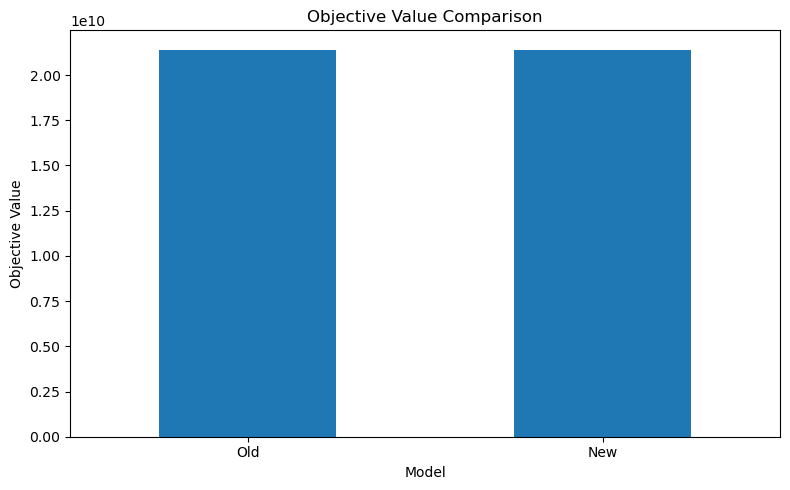

In [12]:
import matplotlib.pyplot as plt

# Plot Objective Values
model_info_df["Objective Value"].plot(
    kind="bar", figsize=(8, 5), title="Objective Value Comparison"
)
plt.ylabel("Objective Value")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

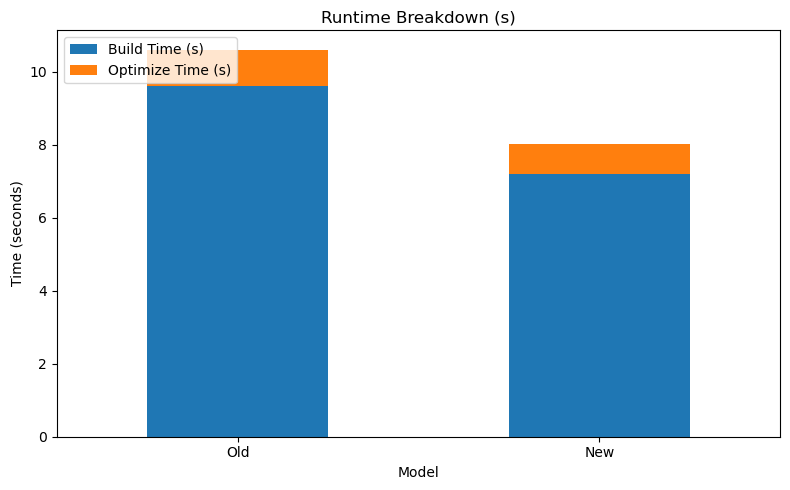

In [13]:
# Plot Runtime Breakdown
model_info_df[["Build Time (s)", "Optimize Time (s)"]].plot(
    kind="bar", stacked=True, figsize=(8, 5), title="Runtime Breakdown (s)"
)
plt.ylabel("Time (seconds)")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [14]:
model_info_df

,Objective Value,Optimality Gap (%),Runtime (s),Build Time (s),Optimize Time (s),Total Time (s),Number of Variables,Number of Constraints,Number of Nonzeros,Number of Integer Variables,Number of Binary Variables,Number of Quadratic Constraints,Model Status
Old,2.140086e+10,NaN,0.962,9.617582,0.983842,10.601423,54516,62586,163473,0,0,0,2
New,2.140086e+10,NaN,0.789,7.204809,0.816318,8.021127,43428,51498,130209,0,0,0,2


In [ ]:
decision_variables = {
    display_names[i]: utils.load_csv_files_from_folder_multi(
        os.path.join(results_folders_to_explore[i], "decision_variables")
    )
    for i in range(len(results_folders_to_explore))
}
old = decision_variables[display_names[0]]
new = decision_variables[display_names[1]]

In [ ]:
old_generation = old["generation"].copy()
new_generation = new["generation"].copy()
print(old_generation["value"].sum())
print(new_generation["value"].sum())

62658657.885688365
62658657.88568838


In [28]:
print(old["power_flow"]["value"].sum())
print(new["power_flow"]["value"].sum())

-10063246.889258234
-10063246.889258232
